In [17]:
import sys
sys.path.insert(0, '../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

In [18]:
# %%
SUBJECT = 'S1'
TRIAL   = 4
SENSOR  = 'Cz'
TSTOP   = 3.0

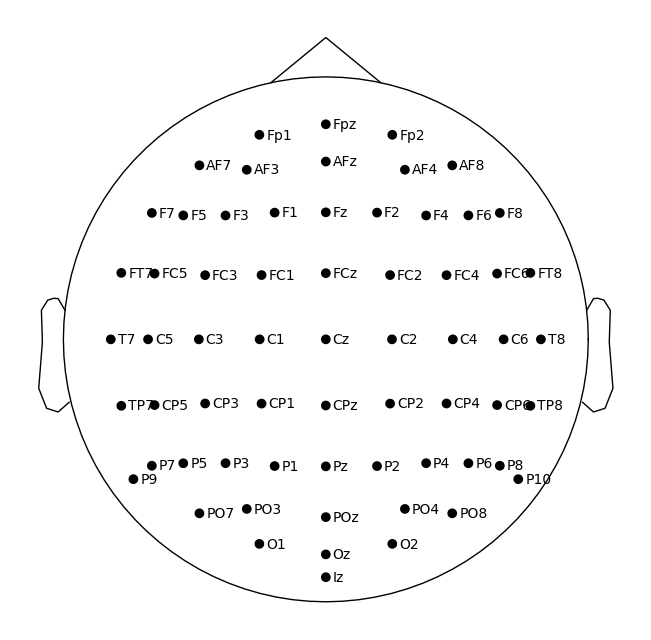

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 64 EEG, 2 misc
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 32.0 Hz
 meas_date: unspecified
 nchan: 66
 projs: []
 sfreq: 64.0 Hz
>

In [19]:
# %%
# MNE setup
montage  = mne.channels.make_standard_montage('biosemi64')
montage.plot()
ch_names = montage.ch_names + ['EXG1', 'EXG2']
ch_types = ['eeg'] * 64 + ['misc', 'misc']
info     = mne.create_info(ch_names, EEG_SAMPLING_RATE, ch_types)
info.set_montage(montage, on_missing='ignore')


In [20]:
# %%
# Load subject data
subject_data_file = helper_functions.get_subject_data_file(SUBJECT)
mat  = scipy.io.loadmat(subject_data_file, squeeze_me=True, struct_as_record=False)
data = mat['data']


# EEG PREPROCESSING

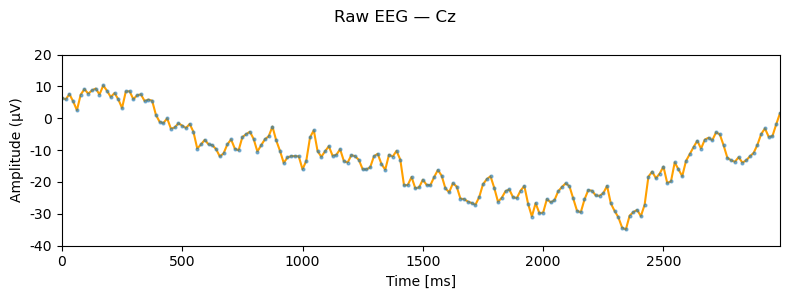

In [21]:
# %%
# --- Step 1: Raw EEG ---
trial = data.eeg[TRIAL]
raw   = mne.io.RawArray(np.array(trial).T * 1e-6, info, verbose=False)

eeg_raw    = eelbrain.load.mne.raw_ndvar(raw).sub(time=(0, TSTOP))
eeg_sensor = eeg_raw.sub(sensor=SENSOR)

fig, ax = plt.subplots(figsize=(8, 3))
eelbrain.plot.UTS(eeg_sensor, axes=ax, ylabel='Amplitude (µV)', title=f'Raw EEG — {SENSOR}')
ax.plot(eeg_sensor.time, eeg_sensor.x, 'o', markersize=2, alpha=0.5)
fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / f'fuglsang_fuglsang_preproc_1_raw_eeg.pdf', bbox_inches='tight')
plt.show()

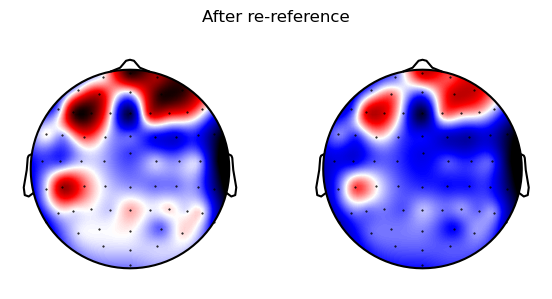

In [22]:
# %%
# --- Step 2: Re-referencing ---
raw.set_eeg_reference(['EXG1', 'EXG2'])
eeg_ref = eelbrain.load.mne.raw_ndvar(raw).sub(time=(0, TSTOP))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
eelbrain.plot.Topomap(eeg_raw.mean('time'),  axes=axes[0], clip='circle', title='Before re-reference')
eelbrain.plot.Topomap(eeg_ref.mean('time'),  axes=axes[1], clip='circle', title='After re-reference')
fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / f'fuglsang_preproc_2_reref_topomap.pdf', bbox_inches='tight')
plt.show()

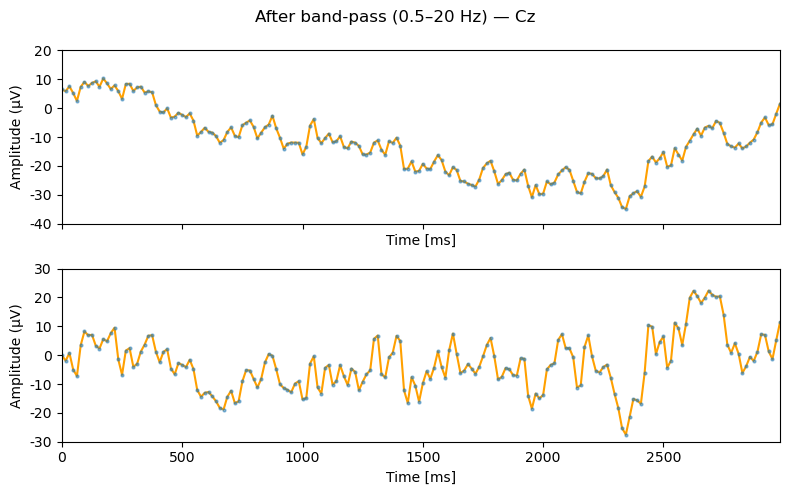

In [23]:
# %%
# --- Step 3: Band-pass filter ---
raw.filter(BANDPASS_FILTER_LOW, BANDPASS_FILTER_HIGH, verbose=False)
eeg_filt = eelbrain.load.mne.raw_ndvar(raw).sub(time=(0, TSTOP)).sub(sensor=SENSOR)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
eelbrain.plot.UTS(eeg_sensor, axes=axes[0], ylabel='Amplitude (µV)', title=f'Before band-pass — {SENSOR}')
eelbrain.plot.UTS(eeg_filt,   axes=axes[1], ylabel='Amplitude (µV)', title=f'After band-pass ({BANDPASS_FILTER_LOW}–{BANDPASS_FILTER_HIGH} Hz) — {SENSOR}')
for ax in axes:
    ax.plot(*([eeg_sensor.time, eeg_sensor.x] if ax == axes[0] else [eeg_filt.time, eeg_filt.x]),
            'o', markersize=2, alpha=0.5)
fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / f'fuglsang_preproc_3_bandpass.pdf', bbox_inches='tight')
plt.show()

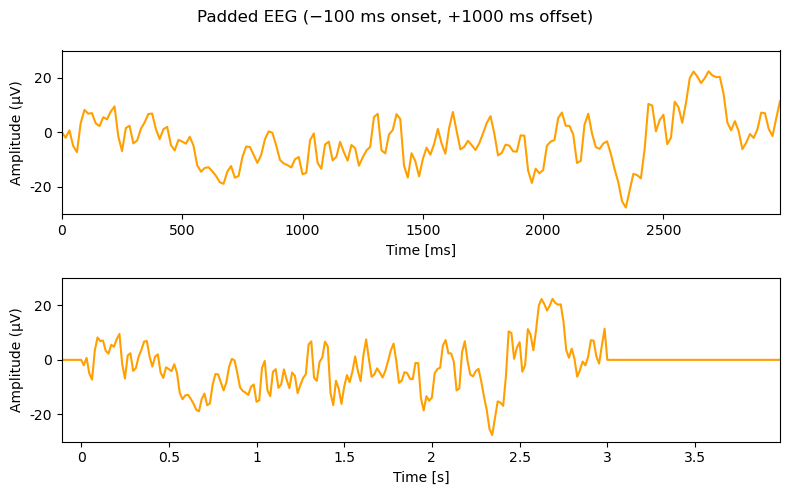

In [24]:
# %%
# --- Step 4: Padding ---
eeg_padded = eelbrain.pad(eeg_filt, tstart=-PADDING_ONSET, tstop=eeg_filt.time.tstop + PADDING_OFFSET)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=False)
eelbrain.plot.UTS(eeg_filt,   axes=axes[0], ylabel='Amplitude (µV)', title='Unpadded EEG')
eelbrain.plot.UTS(eeg_padded, axes=axes[1], ylabel='Amplitude (µV)', title=f'Padded EEG (−{int(PADDING_ONSET*1000)} ms onset, +{int(PADDING_OFFSET*1000)} ms offset)')
fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / f'fuglsang_preproc_4_padding.pdf', bbox_inches='tight')
plt.show()

# AUDIO / PREDICTOR PREPROCESSING

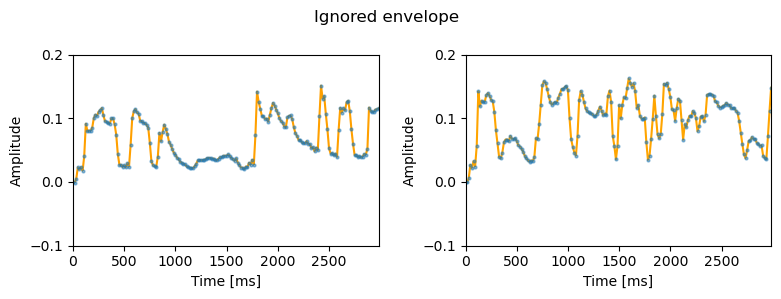

In [25]:
# %%
# --- Step 5: Envelopes ---
att_ndvar   = eelbrain.NDVar(data.wavA[TRIAL], dims=(eelbrain.UTS(0, 1 / data.fsample.wavA, len(data.wavA[TRIAL])),), name='attended').sub(time=(0, TSTOP))
ign_ndvar   = eelbrain.NDVar(data.wavB[TRIAL], dims=(eelbrain.UTS(0, 1 / data.fsample.wavA, len(data.wavB[TRIAL])),), name='ignored').sub(time=(0, TSTOP))

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
eelbrain.plot.UTS(att_ndvar, axes=axes[0], title='Attended envelope',  ylabel='Amplitude')
eelbrain.plot.UTS(ign_ndvar, axes=axes[1], title='Ignored envelope',   ylabel='Amplitude', color='orange')
for ax, ndvar in zip(axes, [att_ndvar, ign_ndvar]):
    ax.plot(ndvar.time, ndvar.x, 'o', markersize=2, alpha=0.5)
fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / f'fuglsang_preproc_5_envelopes.pdf', bbox_inches='tight')
plt.show()

S1: loaded 60 trials


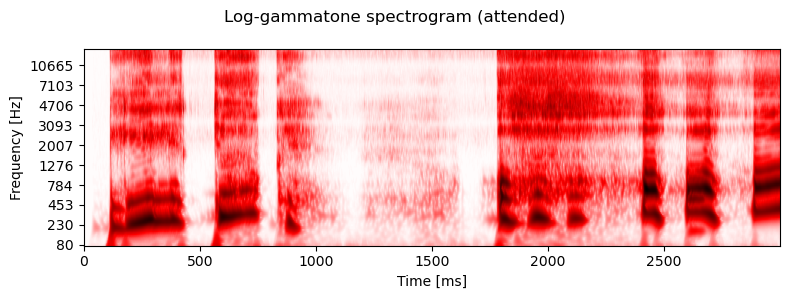

In [26]:
# %%
# --- Step 6: Gammatone spectrogram ---
stimulus_name = helper_functions.get_trials(SUBJECT)[TRIAL]['attended']
gt     = eelbrain.load.unpickle(FUGLSANG_STIMULUS_DIR / f'{stimulus_name}-gammatone.pickle')
gt_log = (gt + 1).log()
gt_sub = gt_log.sub(time=(0, TSTOP))

fig, ax = plt.subplots(figsize=(8, 3))
eelbrain.plot.Array(gt_sub, axes=ax, title='Log-gammatone spectrogram (attended)')
fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / f'fuglsang_preproc_6_gammatone.pdf', bbox_inches='tight')
plt.show()

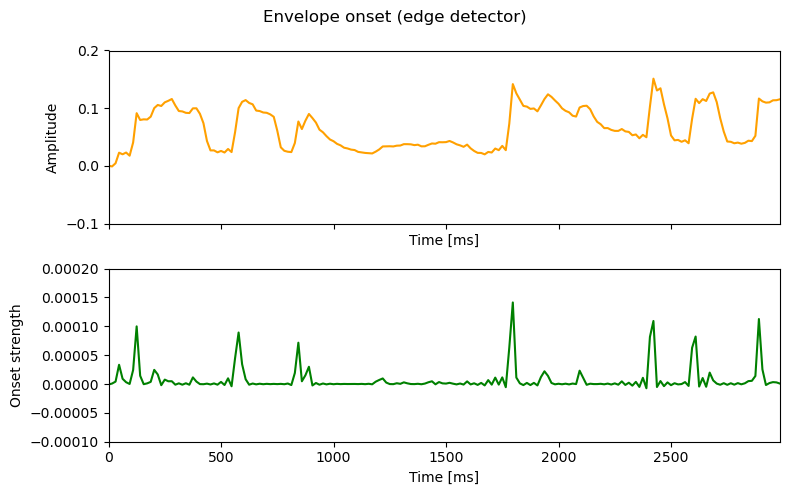

In [27]:
# %%
# --- Step 7: Envelope onset (edge detector) ---
fdim      = eelbrain.Scalar('frequency', [0])
att_2d    = eelbrain.NDVar(att_ndvar.x[None, :], dims=(fdim, att_ndvar.time))
att_1000  = eelbrain.resample(att_2d, 1000)
onset = eelbrain.edge_detector(att_1000, c=30)
onset = eelbrain.resample(onset, EEG_SAMPLING_RATE).mean('frequency')

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
eelbrain.plot.UTS(att_ndvar,   axes=axes[0], ylabel='Amplitude',   title='Attended envelope')
eelbrain.plot.UTS(onset,   axes=axes[1], ylabel='Onset strength', title='Envelope onset (edge detector)', color='green')
fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / f'fuglsang_preproc_7_onset.pdf', bbox_inches='tight')
plt.show()

# Forward vs backward model

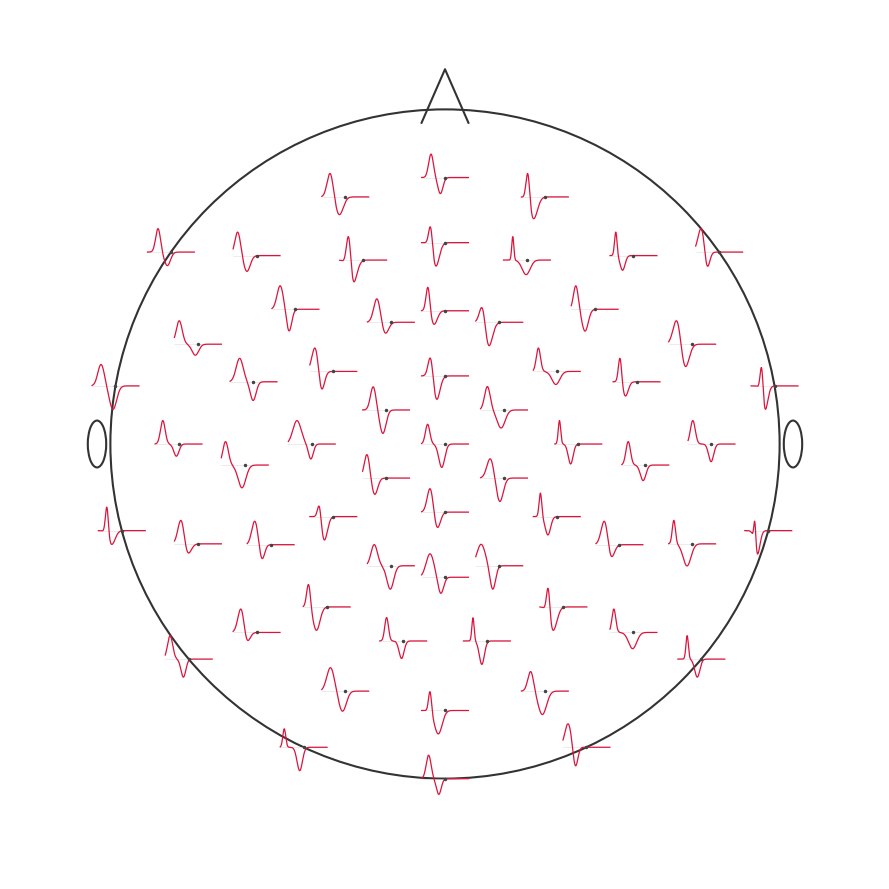

In [28]:
# ── Sensor coordinates (x, y, z on sphere r=9) ───────────────────────────────
coords = np.array([
    [0, 3.517, 8.285], [3.045, 1.758, 8.285], [3.045, -1.758, 8.285],
    [0, -3.517, 8.285], [-3.045, -1.758, 8.285], [-3.045, 1.758, 8.285],
    [0, 8.345, 3.371], [3.394, 7.623, 3.371], [6.201, 5.584, 3.371],
    [7.936, 2.579, 3.371], [8.299, -0.872, 3.371], [7.227, -4.172, 3.371],
    [4.905, -6.751, 3.371], [1.735, -8.162, 3.371], [-1.735, -8.162, 3.371],
    [-4.905, -6.751, 3.371], [-7.227, -4.172, 3.371], [-8.299, -0.872, 3.371],
    [-7.936, 2.579, 3.371], [-6.201, 5.584, 3.371], [-3.394, 7.623, 3.371],
    [6.786, 4.752, -3.517], [8.159, 1.439, -3.517], [8.002, -2.144, -3.517],
    [6.346, -5.325, -3.517], [3.501, -7.508, -3.517], [0, -8.285, -3.517],
    [-3.501, -7.508, -3.517], [-6.346, -5.325, -3.517], [-8.002, -2.144, -3.517],
    [-8.159, 1.439, -3.517], [-6.786, 4.752, -3.517],
    [0, 0, 9], [0, 6.364, 6.364], [2.588, 5.814, 6.364], [5.337, 3.466, 6.364],
    [6.364, 0, 6.364], [5.337, -3.466, 6.364], [2.588, -5.814, 6.364],
    [0, -6.364, 6.364], [-2.588, -5.814, 6.364], [-5.337, -3.466, 6.364],
    [-6.364, 0, 6.364], [-5.337, 3.466, 6.364], [-2.588, 5.814, 6.364],
    [0, 9, 0], [3.371, 8.345, 0], [6.364, 6.364, 0], [8.345, 3.371, 0],
    [9, 0, 0], [8.345, -3.371, 0], [6.364, -6.364, 0], [3.371, -8.345, 0],
    [0, -9, 0], [-3.371, -8.345, 0], [-6.364, -6.364, 0], [-8.345, -3.371, 0],
    [-9, 0, 0], [-8.345, 3.371, 0], [-6.364, 6.364, 0], [-3.371, 8.345, 0],
])

# ── Azimuthal equidistant projection ─────────────────────────────────────────
def project(x, y, z):
    r     = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(np.clip(z / r, -1, 1))
    phi   = np.arctan2(y, x)
    return theta * np.cos(phi), theta * np.sin(phi)

px, py = project(coords[:, 0], coords[:, 1], coords[:, 2])
max_rho = np.max(np.sqrt(px**2 + py**2))
px = px / max_rho
py = py / max_rho

# ── Time axis: 0 to 1 s at 1000 Hz ──────────────────────────────────────────
time = eelbrain.UTS(0, 0.001, 1000)   # tstart=0, tstep=0.001, nsamples=1000

# ── Per-sensor random parameters ─────────────────────────────────────────────
# Seed controls all randomness — change it for a different realisation
rng = np.random.default_rng(seed=42)
N   = len(coords)

# Early positive peak (P1-like, ~80–130 ms)
p1_mean = rng.uniform(0.08, 0.23, N)
p1_std  = rng.uniform(0.02, 0.09, N)
p1_amp  = rng.uniform(0.6,  1.2,  N)

# Negative peak (N2-like, ~200–300 ms)
n2_mean = rng.uniform(0.23, 0.50, N)
n2_std  = rng.uniform(0.05, 0.09, N)
n2_amp  = rng.uniform(0.5,  0.9,  N)

# Noise
noise_std = 0.08

# ── Build ERP signals with eelbrain.gaussian ─────────────────────────────────
# eelbrain.gaussian(UTS, mean_in_seconds, std_in_seconds) -> NDVar
# NDVar supports +/-/* directly; .x gives the underlying numpy array

def make_erp(i):
    pos    = eelbrain.gaussian(p1_mean[i], p1_std[i], time) * p1_amp[i]
    neg    = eelbrain.gaussian(n2_mean[i], n2_std[i], time) * n2_amp[i]
    signal = pos - neg
    noise  = eelbrain.NDVar(rng.normal(0, noise_std, len(time)), dims=(time,)) * 0
    return (signal + noise).x   # numpy array, shape (1000,)

signals = [make_erp(i) for i in range(N)]
t_axis  = time.times            # 0.000 … 0.999 s

# ── Plot ──────────────────────────────────────────────────────────────────────
SQUIGGLE_SIZE = 0.07   # half-width of each mini-plot in head-radius units

fig, ax = plt.subplots(figsize=(9, 9))
ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)

# Head circle
ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, color='#333', lw=1.5, zorder=2))

# Nose (top = anterior)
ax.plot([-0.07, 0, 0.07], [0.96, 1.12, 0.96], color='#333', lw=1.5, zorder=2)

# Ears
for side in [-1, 1]:
    ax.add_patch(plt.matplotlib.patches.Ellipse(
        (side * 1.04, 0), width=0.055, height=0.14,
        fill=False, color='#333', lw=1.5, zorder=2))

# Rescale time axis to [-1, 1] for placement around sensor centre
t_norm = (t_axis / t_axis[-1]) * 2 - 1

for i in range(N):
    cx, cy = px[i], py[i]
    y_raw  = signals[i]

    # Normalise amplitude to fit within SQUIGGLE_SIZE
    y_range = np.max(np.abs(y_raw)) or 1.0
    y_norm  = y_raw / y_range * SQUIGGLE_SIZE

    x_plot = cx + t_norm * SQUIGGLE_SIZE
    y_plot = cy + y_norm

    # Zero baseline
    ax.plot([cx - SQUIGGLE_SIZE, cx + SQUIGGLE_SIZE], [cy, cy],
            color='#ddd', lw=0.4, zorder=3)
    # ERP squiggle
    ax.plot(x_plot, y_plot, color='crimson', lw=0.9, zorder=4)
    
    # Sensor dot
    ax.plot(cx, cy, 'o', color='#444', ms=1.5, zorder=5)

plt.tight_layout()
#plt.savefig('scalp_squiggles.png', dpi=150, bbox_inches='tight')
plt.show()



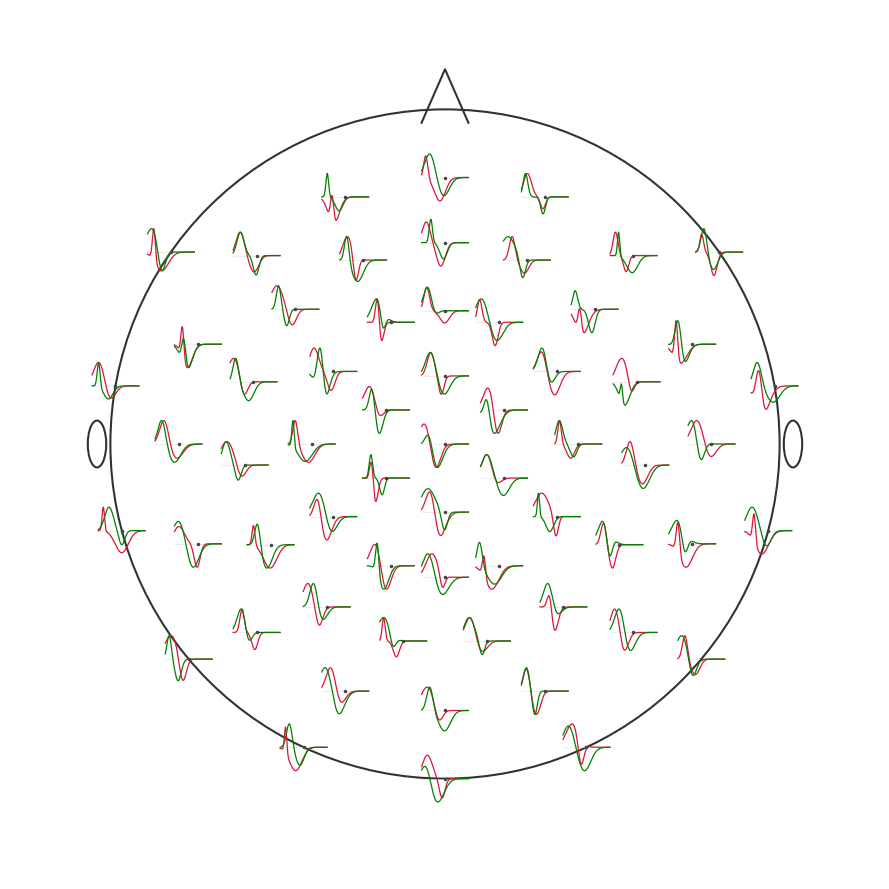

In [ ]:
# ── Time axis: 0 to 1 s at 1000 Hz ──────────────────────────────────────────
time = eelbrain.UTS(0, 0.001, 1000)   # tstart=0, tstep=0.001, nsamples=1000

# ── Per-sensor random parameters ─────────────────────────────────────────────
# Seed controls all randomness — change it for a different realisation
rng = np.random.default_rng(seed=42)
N   = len(coords)

# ── Build ERP signals with eelbrain.gaussian ─────────────────────────────────
# eelbrain.gaussian(UTS, mean_in_seconds, std_in_seconds) -> NDVar
# NDVar supports +/-/* directly; .x gives the underlying numpy array

def make_erp():
    pos    = eelbrain.gaussian(rng.uniform(0.08, 0.23), rng.uniform(0.02, 0.15), time) * rng.uniform(0.6,  1.2)
    neg    = eelbrain.gaussian(rng.uniform(0.23, 0.50), rng.uniform(0.05, 0.15), time) * rng.uniform(0.5,  0.9)
    signal = pos - neg
    return (signal).x   # numpy array, shape (1000,)

signals = [make_erp() for i in range(N)]
signals2 = [make_erp() for i in range(N)]
t_axis  = time.times            # 0.000 … 0.999 s

# ── Plot ──────────────────────────────────────────────────────────────────────
SQUIGGLE_SIZE = 0.07   # half-width of each mini-plot in head-radius units

fig, ax = plt.subplots(figsize=(9, 9))
ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)

# Head circle
ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, color='#333', lw=1.5, zorder=2))

# Nose (top = anterior)
ax.plot([-0.07, 0, 0.07], [0.96, 1.12, 0.96], color='#333', lw=1.5, zorder=2)

# Ears
for side in [-1, 1]:
    ax.add_patch(plt.matplotlib.patches.Ellipse(
        (side * 1.04, 0), width=0.055, height=0.14,
        fill=False, color='#333', lw=1.5, zorder=2))

# Rescale time axis to [-1, 1] for placement around sensor centre
t_norm = (t_axis / t_axis[-1]) * 2 - 1

for i in range(N):
    cx, cy = px[i], py[i]
    y_raw  = signals[i]
    y_raw2  = signals2[i]

    # Normalise amplitude to fit within SQUIGGLE_SIZE
    y_range = np.max(np.abs(y_raw)) or 1.0
    y_norm  = y_raw / y_range * SQUIGGLE_SIZE

    y_range2 = np.max(np.abs(y_raw2)) or 1.0
    y_norm2  = y_raw2 / y_range2 * SQUIGGLE_SIZE

    x_plot = cx + t_norm * SQUIGGLE_SIZE
    y_plot = cy + y_norm

    x_plot2 = cx + t_norm * SQUIGGLE_SIZE
    y_plot2 = cy + y_norm2

    # Zero baseline
    ax.plot([cx - SQUIGGLE_SIZE, cx + SQUIGGLE_SIZE], [cy, cy],
            color='#ddd', lw=0.4, zorder=3)
    # ERP squiggle
    ax.plot(x_plot, y_plot, color='crimson', lw=0.9, zorder=4)
    ax.plot(x_plot2, y_plot2, color='green', lw=0.9, zorder=4)
    # Sensor dot
    ax.plot(cx, cy, 'o', color='#444', ms=1.5, zorder=5)

plt.tight_layout()
#plt.savefig(FUGLSANG_FIGURES_DIR / 'scalp_squiggles.png', dpi=150, bbox_inches='tight')
plt.show()



S1: loaded 60 trials


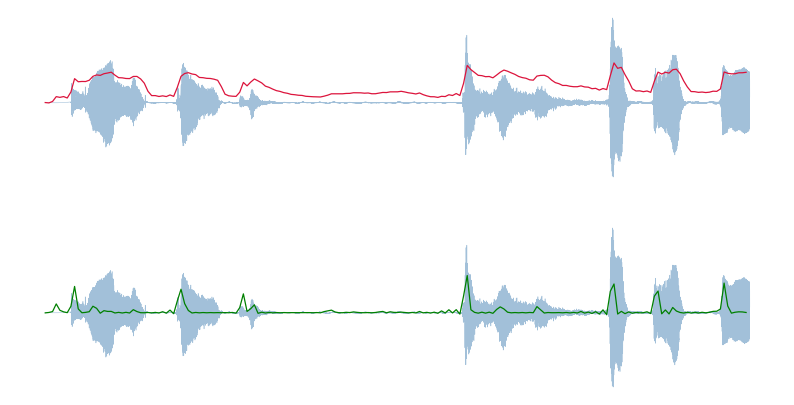

In [30]:

stimulus_name = helper_functions.get_trials(SUBJECT)[TRIAL]['attended']
wav_path = FUGLSANG_STIMULUS_DIR / f'{stimulus_name}.wav'

# Load .wav
sr, data = scipy.io.wavfile.read(wav_path)

# If stereo, take first channel
if data.ndim > 1:
    data = data[:, 0]

# Normalize
data = data.astype(np.float64)
data /= np.max(np.abs(data))

# Time axis — crop to TSTOP
t = np.arange(len(data)) / sr
mask = t <= TSTOP
t = t[mask]
data = data[mask]

# Amplitude envelope via Hilbert transform
fdim      = eelbrain.Scalar('frequency', [0])
envelope    = eelbrain.NDVar(att_ndvar.x[None, :], dims=(fdim, att_ndvar.time))
envelope_1000  = eelbrain.resample(envelope, 1000)
onset = eelbrain.edge_detector(envelope_1000, c=30)
onset = eelbrain.resample(onset, EEG_SAMPLING_RATE).mean('frequency')


# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Top: waveform + envelope
ax1.plot(t, data, color='steelblue', alpha=0.5, linewidth=0.4, label='Waveform')
ax1.plot(envelope.time.times, envelope.x[0], color='crimson', linewidth=0.9, label='Envelope')
ax1.axis('off')

# Bottom: onset
ax2.plot(t, data, color='steelblue', alpha=0.5, linewidth=0.4, label='Waveform')
ax2.plot(onset.time.times, onset.x * 1000, color='green', linewidth=0.9, label='Onset')
ax2.axis('off')


#ax.plot(t, -envelope, color='crimson', linewidth=1.5)  # mirror lower bound

ax.set_xlim(t[0], t[-1])
#ax.set_xlabel('Time (s)')
#ax.set_ylabel('Amplitude')
#ax.set_title(f'Audio signal + envelope — {stimulus_name}')
#ax.legend(loc='upper right')
ax.axis('off')

ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))


#fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / f'fuglsang_preproc_audio_envelope.pdf', bbox_inches='tight')
plt.show()